# MarketMinds — Phase 3b: Nonlinear Models (Random Forest + XGBoost)

Phase 3 found that linear regression never showed real directional skill anywhere, while ARIMA showed real skill in calm markets (40% of assets significantly better than random) that flipped to significantly worse than random in COVID (35% of assets). This notebook asks: do nonlinear models find real signal in the same 8 technical-indicator features that linear regression missed, or do they collapse under regime shifts too?

Everything is kept identical to Phase 3 except the model itself, so the comparison is fair:
- **Same features**, reused from `data/processed/marketminds_master.parquet` via `src.forecasting.FEATURE_COLS` -- nothing re-derived.
- **Same target**: 5-trading-day-forward log return, no lookahead.
- **Same three windows**: `normal` (2017), `2008_financial_crisis`, `covid_crash`.
- **Same basket** and the same minimum-training-history skip logic (GOLDBEES.NS before 2008, etc.).
- **Same significance test** against 50% random chance, split into significantly-better vs. significantly-worse.

**One real methodological difference, disclosed rather than hidden**: Random Forest and XGBoost are refit every 20 trading days (~monthly) on an expanding window, not daily like linear regression/ARIMA were. Refitting a 200-tree ensemble at every single test day across ~21 assets x 3 windows would mean well over 10,000 fits -- computationally excessive for a notebook run on a laptop. No-lookahead still holds (every prediction only uses a model trained on strictly earlier data), it's just not refreshed as of yesterday specifically. See `src/forecasting.py`'s `train_eval_tree_model` for the implementation.

**Runtime note**: expect several minutes, not seconds -- progress prints below.

**Note on execution**: same as always — you run every cell, I don't execute anything. Paste back any errors.

## Setup

In [11]:
import json
import pickle
import sys
import time
import warnings
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pyarrow.parquet as pq
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)

PROJECT_ROOT = Path('..').resolve()
PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed'
MODELS_DIR = PROJECT_ROOT / 'models'
RESULTS_DIR = PROJECT_ROOT / 'results'
MODELS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
sys.path.append(str(PROJECT_ROOT))

from src.forecasting import FEATURE_COLS, TARGET_COL, build_feature_target_table, compute_eval_metrics, train_eval_tree_model, safe_asset_name

master = pq.read_table(PROCESSED_DIR / 'marketminds_master.parquet').to_pandas()
symbol_metadata = pq.read_table(PROCESSED_DIR / 'symbol_metadata.parquet').to_pandas()
print('Master shape:', master.shape)
print('Features (reused from Phase 1, unchanged):', FEATURE_COLS)

Master shape: (134646, 18)
Features (reused from Phase 1, unchanged): ['daily_return', 'ma_20', 'ma_50', 'ma_200', 'rsi_14', 'macd', 'macd_signal', 'volatility_20d']


## 1. Reuse Phase 3's windows and basket definitions

Identical to `04_model_validation_full_basket.ipynb` -- same three windows, same basket (everything except India VIX), same minimum-training-rows skip threshold.

In [12]:
ASSETS = sorted(t for t in master['ticker'].unique() if t != '^INDIAVIX')

WINDOWS = {
    'normal': {'train_end': '2016-12-31', 'test_start': '2017-01-01', 'test_end': '2017-12-31'},
    '2008_financial_crisis': {'train_end': '2007-12-31', 'test_start': '2008-01-01', 'test_end': '2009-03-31'},
    'covid_crash': {'train_end': '2019-12-31', 'test_start': '2020-02-20', 'test_end': '2020-04-30'},
}

MIN_TRAIN_ROWS = 250

print(len(ASSETS), 'assets:', ASSETS)

20 assets: ['DRREDDY.NS', 'GOLDBEES.NS', 'HDFCBANK.NS', 'HINDUNILVR.NS', 'ICICIBANK.NS', 'INFY.NS', 'ITC.NS', 'KOTAKBANK.NS', 'LT.NS', 'MARUTI.NS', 'NESTLEIND.NS', 'ONGC.NS', 'RELIANCE.NS', 'SUNPHARMA.NS', 'TATASTEEL.NS', 'TCS.NS', 'ULTRACEMCO.NS', 'WIPRO.NS', '^BSESN', '^NSEI']


## 2. Model configurations

Moderately regularized, not deeply tuned -- consistent with these still being baselines for a nonlinear comparison, not a tuned production model. `max_depth` and `min_samples_leaf`/`subsample` are set conservatively since each window only has a few thousand training rows and 8 features; an untuned deep ensemble would be prone to overfitting noise in daily return data.

In [13]:
REFIT_EVERY = 20  # trading days (~1 month) between refits -- see the title cell for why

def make_random_forest():
    return RandomForestRegressor(n_estimators=200, max_depth=5, min_samples_leaf=20, random_state=42, n_jobs=-1)

def make_xgboost():
    return XGBRegressor(n_estimators=200, max_depth=4, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1)

MODEL_FACTORIES = {
    'random_forest': make_random_forest,
    'xgboost': make_xgboost,
}

## 3. Train, evaluate, and save Random Forest + XGBoost across the full basket

For each (asset, window, model): walk-forward evaluate, compute metrics, save the model + metadata immediately (same convention as Phase 3: asset, model type, window, train/test dates, metrics, date trained), and collect Random Forest's feature importances for Step 7. Models are saved per (asset, model, window) -- expect roughly 20 assets x 2 models x 3 windows worth of files in `models/` (the `.pkl` binaries are gitignored, only the small `.json` metadata files get committed).

In [14]:
def save_model(model_obj, model_type, ticker, window_name, cfg, metrics):
    asset_name = safe_asset_name(ticker)
    base = model_type + '_' + asset_name + '_' + window_name
    model_path = MODELS_DIR / (base + '.pkl')
    meta_path = MODELS_DIR / (base + '.json')

    with open(model_path, 'wb') as f:
        pickle.dump(model_obj, f)

    metadata = {
        'asset': ticker,
        'model_type': model_type,
        'window': window_name,
        'train_end': cfg['train_end'],
        'test_start': cfg['test_start'],
        'test_end': cfg['test_end'],
        'metrics': metrics,
        'date_trained': datetime.now().isoformat(),
    }
    with open(meta_path, 'w') as f:
        json.dump(metadata, f, indent=2)

In [15]:
results = []
importance_records = []
start_time = time.time()

for i, ticker in enumerate(ASSETS, 1):
    asset_df = master[master['ticker'] == ticker]
    feature_table = build_feature_target_table(asset_df)
    print(f'[{i}/{len(ASSETS)}] {ticker} -- feature table: {len(feature_table)} rows, elapsed {time.time() - start_time:.0f}s')

    for window_name, cfg in WINDOWS.items():
        train_rows = len(feature_table.loc[:cfg['train_end']])
        test_rows = len(feature_table.loc[cfg['test_start']:cfg['test_end']])

        if train_rows < MIN_TRAIN_ROWS or test_rows == 0:
            for model_name in MODEL_FACTORIES:
                results.append({
                    'ticker': ticker, 'window': window_name, 'model': model_name,
                    'status': 'skipped_insufficient_history',
                    'mae_pct': np.nan, 'rmse_pct': np.nan, 'directional_accuracy_pct': np.nan,
                    'dir_acc_ci_low': np.nan, 'dir_acc_ci_high': np.nan,
                    'p_value_vs_random': np.nan, 'significant_vs_random': False,
                    'significant_better_than_random': False, 'significant_worse_than_random': False,
                    'n_predictions': train_rows,
                })
            continue

        for model_name, factory in MODEL_FACTORIES.items():
            pred, actual, fitted_model, importances = train_eval_tree_model(feature_table, cfg, factory, refit_every=REFIT_EVERY)
            metrics = compute_eval_metrics(actual, pred)
            results.append({'ticker': ticker, 'window': window_name, 'model': model_name, 'status': 'ok', **metrics})
            save_model(fitted_model, model_name, ticker, window_name, cfg, metrics)

            if importances is not None:
                for feature, importance in importances.items():
                    importance_records.append({'ticker': ticker, 'window': window_name, 'model': model_name, 'feature': feature, 'importance': importance})

print(f'Done in {time.time() - start_time:.0f}s -- {len(results)} rows, {len(importance_records)} importance records')
nonlinear_results_df = pd.DataFrame(results)

[1/20] DRREDDY.NS -- feature table: 6738 rows, elapsed 0s
[2/20] GOLDBEES.NS -- feature table: 4389 rows, elapsed 20s
[3/20] HDFCBANK.NS -- feature table: 6738 rows, elapsed 29s
[4/20] HINDUNILVR.NS -- feature table: 6738 rows, elapsed 49s
[5/20] ICICIBANK.NS -- feature table: 6088 rows, elapsed 70s
[6/20] INFY.NS -- feature table: 6738 rows, elapsed 89s
[7/20] ITC.NS -- feature table: 6738 rows, elapsed 109s
[8/20] KOTAKBANK.NS -- feature table: 6348 rows, elapsed 129s
[9/20] LT.NS -- feature table: 6088 rows, elapsed 149s
[10/20] MARUTI.NS -- feature table: 5821 rows, elapsed 169s
[11/20] NESTLEIND.NS -- feature table: 6058 rows, elapsed 188s
[12/20] ONGC.NS -- feature table: 6738 rows, elapsed 204s
[13/20] RELIANCE.NS -- feature table: 6738 rows, elapsed 224s
[14/20] SUNPHARMA.NS -- feature table: 6738 rows, elapsed 244s
[15/20] TATASTEEL.NS -- feature table: 6738 rows, elapsed 264s
[16/20] TCS.NS -- feature table: 6058 rows, elapsed 285s
[17/20] ULTRACEMCO.NS -- feature table: 6058

## 4. Merge sector metadata, save detailed nonlinear results

In [16]:
nonlinear_results_df = nonlinear_results_df.merge(symbol_metadata, on='ticker', how='left')
cols = ['ticker', 'category', 'window', 'model', 'status', 'mae_pct', 'rmse_pct',
        'directional_accuracy_pct', 'dir_acc_ci_low', 'dir_acc_ci_high',
        'p_value_vs_random', 'significant_vs_random',
        'significant_better_than_random', 'significant_worse_than_random', 'n_predictions']
nonlinear_results_df = nonlinear_results_df[cols]

nonlinear_path = RESULTS_DIR / 'nonlinear_model_validation_full_basket.csv'
nonlinear_results_df.to_csv(nonlinear_path, index=False)
print('Saved', len(nonlinear_results_df), 'rows to', nonlinear_path)
nonlinear_results_df.head(10)

Saved 120 rows to /Users/palakjagtap/Documents/Market_minds/results/nonlinear_model_validation_full_basket.csv


,ticker,category,window,model,status,mae_pct,rmse_pct,directional_accuracy_pct,dir_acc_ci_low,dir_acc_ci_high,p_value_vs_random,significant_vs_random,significant_better_than_random,significant_worse_than_random,n_predictions
0,DRREDDY.NS,Pharma,normal,random_forest,ok,3.046,4.162,46.9,40.9,53.0,0.3211,False,False,False,260
1,DRREDDY.NS,Pharma,normal,xgboost,ok,3.187,4.269,50.0,44.0,56.0,1.0000,False,False,False,260
2,DRREDDY.NS,Pharma,2008_financial_crisis,random_forest,ok,4.539,5.860,44.2,38.9,49.6,0.0353,True,False,True,326
3,DRREDDY.NS,Pharma,2008_financial_crisis,xgboost,ok,4.732,6.086,47.9,42.5,53.3,0.4381,False,False,False,326
4,DRREDDY.NS,Pharma,covid_crash,random_forest,ok,7.027,8.573,47.1,34.1,60.5,0.6744,False,False,False,51
5,DRREDDY.NS,Pharma,covid_crash,xgboost,ok,8.695,10.650,33.3,22.0,47.0,0.0173,True,False,True,51
6,GOLDBEES.NS,Gold,normal,random_forest,ok,1.059,1.306,58.8,52.8,64.7,0.0043,True,True,False,260
7,GOLDBEES.NS,Gold,normal,xgboost,ok,1.046,1.297,52.3,46.2,58.3,0.4568,False,False,False,260
8,GOLDBEES.NS,Gold,2008_financial_crisis,random_forest,skipped_insufficient_history,NaN,NaN,NaN,NaN,NaN,NaN,False,False,False,0
9,GOLDBEES.NS,Gold,2008_financial_crisis,xgboost,skipped_insufficient_history,NaN,NaN,NaN,NaN,NaN,NaN,False,False,False,0


## 5. Combine with Phase 3 baseline results into an all-four-models view

Loads Phase 3's saved `baseline_model_validation_full_basket.csv` (linear regression + ARIMA) and stacks it with this notebook's Random Forest + XGBoost results, then shows mean MAE/RMSE/directional accuracy per model per window as a first side-by-side look before the significance breakdown.

In [17]:
baseline_path = RESULTS_DIR / 'baseline_model_validation_full_basket.csv'
baseline_results_df = pd.read_csv(baseline_path)

combined_df = pd.concat([baseline_results_df, nonlinear_results_df], ignore_index=True)
print('Combined shape:', combined_df.shape)
print('Models included:', sorted(combined_df['model'].unique()))

ok_df = combined_df[combined_df['status'] == 'ok']
ok_df.groupby(['model', 'window'])[['mae_pct', 'rmse_pct', 'directional_accuracy_pct']].mean().round(3)

Combined shape: (240, 16)
Models included: ['arima', 'linear_regression', 'random_forest', 'xgboost']


mae_pct  rmse_pct  \
model             window                                     
arima             2008_financial_crisis    5.652     7.227   
                  covid_crash              7.009     8.878   
                  normal                   2.090     2.792   
linear_regression 2008_financial_crisis    5.559     7.150   
                  covid_crash              7.655     9.600   
                  normal                   2.130     2.839   
random_forest     2008_financial_crisis    5.728     7.322   
                  covid_crash              8.389    10.251   
                  normal                   2.164     2.882   
xgboost           2008_financial_crisis    5.928     7.544   
                  covid_crash              8.564    11.505   
                  normal                   2.389     3.144   

                                         directional_accuracy_pct  
model             window                                           
arima             2008_financial_crisis                    45.939  
                  covid_crash                              41.270  
                  normal                                   55.375  
linear_regression 2008_financial_crisis                    54.583  
                  covid_crash                              50.795  
                  normal                                   52.590  
random_forest     2008_financial_crisis                    51.156  
                  covid_crash                              37.950  
                  normal                                   52.790  
xgboost           2008_financial_crisis                    53.244  
                  covid_crash                              42.555  
                  normal                                   51.075

## 6. Four-model significance comparison (main output)

Same format as Phase 3's `phase3_significance_summary.csv`, now with all four models -- this is the table that actually answers the question this notebook was built for: does either nonlinear model show a Phase-3-style flip from significant skill to significant anti-skill, or something different?

In [26]:
comparison = combined_df[combined_df['status'] == 'ok'].groupby(['model', 'window']).agg(
    total_assets=('ticker', 'count'),
    significant_better=('significant_better_than_random', 'sum'),
    significant_worse=('significant_worse_than_random', 'sum'),
).reset_index()
comparison['pct_significant_better'] = (comparison['significant_better'] / comparison['total_assets'] * 100).round(1)
comparison['pct_significant_worse'] = (comparison['significant_worse'] / comparison['total_assets'] * 100).round(1)

comparison_path = RESULTS_DIR / 'phase3b_nonlinear_comparison.csv'
comparison.to_csv(comparison_path, index=False)
print('Saved to', comparison_path)
comparison

Saved to /Users/palakjagtap/Documents/Market_minds/results/phase3b_nonlinear_comparison.csv


,model,window,total_assets,significant_better,significant_worse,pct_significant_better,pct_significant_worse
0,arima,2008_financial_crisis,18,1,4,5.6,22.2
1,arima,covid_crash,20,0,7,0.0,35.0
2,arima,normal,20,8,0,40.0,0.0
3,linear_regression,2008_financial_crisis,18,5,0,27.8,0.0
4,linear_regression,covid_crash,20,0,0,0.0,0.0
5,linear_regression,normal,20,6,1,30.0,5.0
6,random_forest,2008_financial_crisis,18,3,4,16.7,22.2
7,random_forest,covid_crash,20,1,10,5.0,50.0
8,random_forest,normal,20,10,3,50.0,15.0
9,xgboost,2008_financial_crisis,18,3,1,16.7,5.6


## 6b. Sanity check: is XGBoost's normal-window result an under-fitting artifact?

XGBoost showed only 15% significant skill in `normal` -- well below Random Forest's 50% and even below linear regression's 30% -- despite being a nonlinear model too. Before trusting that number for the write-up, checking whether it's a real result or just an artifact of the regularization settings (`max_depth=4`, `subsample=0.8`, `colsample_bytree=0.8`) being too conservative. Quick check on 4 assets, `normal` window only: a meaningfully less-regularized config (deeper trees, more estimators, no sub-sampling) against the original, comparing directional accuracy and the significance flag directly.

In [23]:
SANITY_CHECK_ASSETS = ['RELIANCE.NS', 'TCS.NS', 'HDFCBANK.NS', '^BSESN']

def make_xgboost_less_regularized():
    return XGBRegressor(n_estimators=400, max_depth=6, learning_rate=0.05, subsample=1.0, colsample_bytree=1.0, random_state=42, n_jobs=-1)

sanity_results = []
normal_cfg = WINDOWS['normal']

for ticker in SANITY_CHECK_ASSETS:
    asset_df = master[master['ticker'] == ticker]
    feature_table = build_feature_target_table(asset_df)

    pred_orig, actual_orig, _, _ = train_eval_tree_model(feature_table, normal_cfg, make_xgboost, refit_every=REFIT_EVERY)
    metrics_orig = compute_eval_metrics(actual_orig, pred_orig)

    pred_alt, actual_alt, _, _ = train_eval_tree_model(feature_table, normal_cfg, make_xgboost_less_regularized, refit_every=REFIT_EVERY)
    metrics_alt = compute_eval_metrics(actual_alt, pred_alt)

    sanity_results.append({
        'ticker': ticker,
        'original_dir_acc_pct': metrics_orig['directional_accuracy_pct'],
        'original_significant_better': metrics_orig['significant_better_than_random'],
        'less_regularized_dir_acc_pct': metrics_alt['directional_accuracy_pct'],
        'less_regularized_significant_better': metrics_alt['significant_better_than_random'],
    })
    print(ticker, 'done')

sanity_df = pd.DataFrame(sanity_results)
sanity_df

RELIANCE.NS done
TCS.NS done
HDFCBANK.NS done
^BSESN done


,ticker,original_dir_acc_pct,original_significant_better,less_regularized_dir_acc_pct,less_regularized_significant_better
0,RELIANCE.NS,50.0,False,50.0,False
1,TCS.NS,49.2,False,51.5,False
2,HDFCBANK.NS,62.3,True,58.5,True
3,^BSESN,45.8,False,51.5,False


## 7. Random Forest feature importance: normal vs. crisis regime

Mean feature importance across all assets, split by window -- if the model leans on different signals depending on the regime (e.g. relying more on volatility/RSI during crises and more on moving averages/MACD in calm markets), that shows up here as a re-ranking between columns.

In [24]:
importance_df = pd.DataFrame(importance_records)
rf_importance = importance_df[importance_df['model'] == 'random_forest']

importance_summary = rf_importance.groupby(['window', 'feature'])['importance'].mean().unstack('window')
importance_summary = importance_summary[['normal', '2008_financial_crisis', 'covid_crash']]
importance_summary = importance_summary.sort_values('normal', ascending=False)
importance_summary

window,normal,2008_financial_crisis,covid_crash
feature,,,
ma_200,0.218993,0.224625,0.250185
volatility_20d,0.148722,0.122976,0.157911
ma_20,0.144890,0.095176,0.119065
rsi_14,0.130841,0.107425,0.123937
ma_50,0.129008,0.122805,0.139111
macd_signal,0.090712,0.099864,0.087967
macd,0.085690,0.115744,0.071132
daily_return,0.051144,0.055828,0.050691


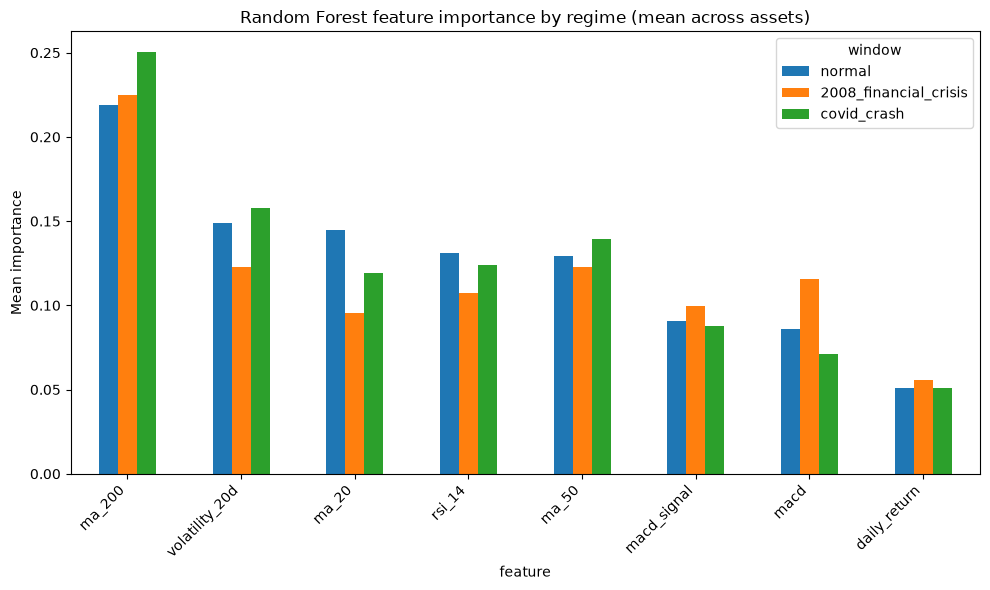

In [25]:
fig, ax = plt.subplots(figsize=(10, 6))
importance_summary.plot(kind='bar', ax=ax)
ax.set_title('Random Forest feature importance by regime (mean across assets)')
ax.set_ylabel('Mean importance')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Summary

What this notebook produced:
- `results/nonlinear_model_validation_full_basket.csv` -- detailed per-asset Random Forest + XGBoost results, same format as Phase 3's baseline file
- `results/phase3b_nonlinear_comparison.csv` -- all four models (linear regression, ARIMA, Random Forest, XGBoost) x three windows, significance-summary format, the main comparison output
- Trained Random Forest + XGBoost models in `models/` (one per asset/window, `.pkl` + `.json` metadata each)
- Step 7's feature importance breakdown by regime

The question this was built to answer: **do Random Forest and XGBoost find real signal the linear models missed, or do they fail the same way?** Compare Step 6's `pct_significant_better`/`pct_significant_worse` columns for `random_forest`/`xgboost` against `linear_regression`/`arima` across the three windows to see which story the data tells.

Next: depending on what Step 6 shows, either move to the LSTM (per the proposal's model roadmap) or, if nonlinear models don't add real signal, treat that as its own honest finding and move toward the Next.js frontend / app integration instead.